In [1]:
import pandas as pd;
from pathlib import Path
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_parquet("../data/processed/cleaned_taxi_data.parquet")
df.shape

(13606730, 26)

In [5]:
sample_df = df.sample(100000, random_state=42)
sample_df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,is_weekend
count,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.782600,2026-03-20 19:14:14.262639,2026-03-20 19:31:55.104040,1.242820,3.428191,5.683180,165.324810,164.498320,1.140410,19.737291,...,29.309744,2.220475,0.157582,0.530220,17.680690,14.411470,15.587240,3.121270,3.007620,0.263310
min,1.000000,2026-01-01 00:06:17,2026-01-01 00:12:08,1.000000,0.010000,1.000000,1.000000,1.000000,1.000000,0.010000,...,4.500000,0.000000,0.000000,0.000000,0.016667,0.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,2026-02-11 18:29:49.500000,2026-02-11 18:49:56.750000,1.000000,1.000000,1.000000,132.000000,113.000000,1.000000,9.300000,...,16.750000,2.500000,0.000000,0.000000,7.866667,11.000000,8.000000,2.000000,1.000000,0.000000
50%,2.000000,2026-03-22 11:38:52,2026-03-22 11:44:57,1.000000,1.700000,1.000000,162.000000,162.000000,1.000000,13.500000,...,21.900000,2.500000,0.000000,0.750000,13.016667,15.000000,15.000000,3.000000,3.000000,0.000000
75%,2.000000,2026-04-27 11:28:07.750000,2026-04-27 11:48:11.750000,1.000000,3.370000,1.000000,234.000000,234.000000,1.000000,22.600000,...,31.577500,2.500000,0.000000,0.750000,21.650000,19.000000,23.000000,4.000000,5.000000,1.000000
max,2.000000,2026-05-31 23:58:59,2026-06-01 00:23:27,6.000000,187.400000,99.000000,265.000000,265.000000,4.000000,439.800000,...,462.340000,2.500000,2.000000,0.750000,179.500000,23.000000,31.000000,5.000000,6.000000,1.000000
std,0.412479,NaN,NaN,0.638438,4.558111,20.734803,63.788489,69.662703,0.403753,17.767428,...,22.274205,0.787835,0.523010,0.341369,15.662387,5.575686,8.642881,1.411391,1.891713,0.440431


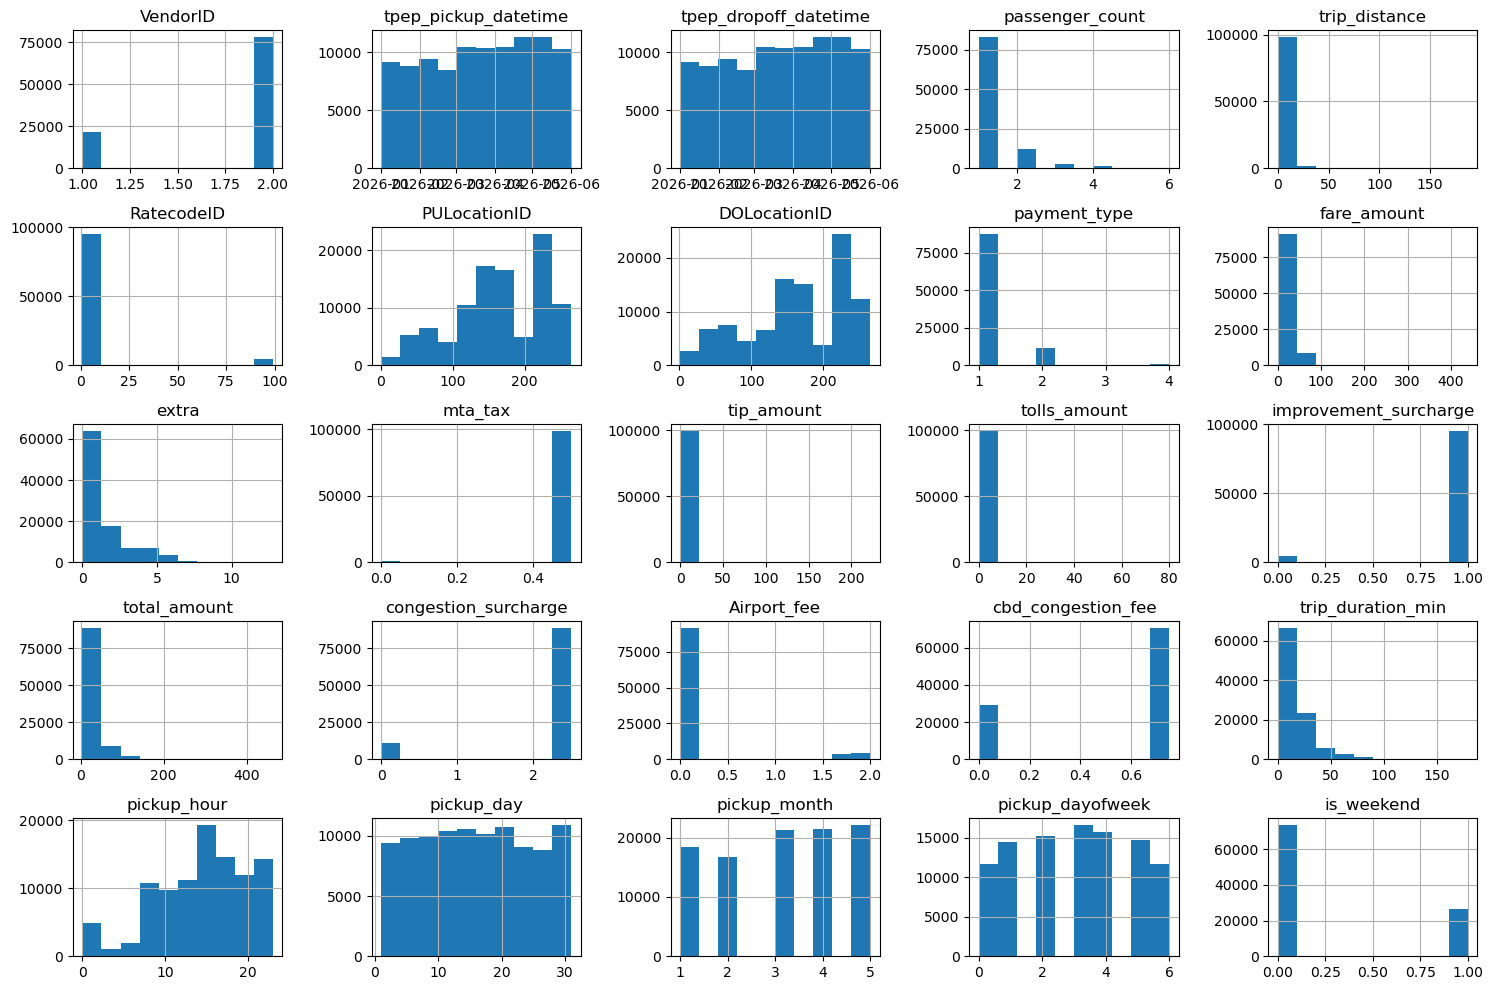

In [6]:
sample_df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

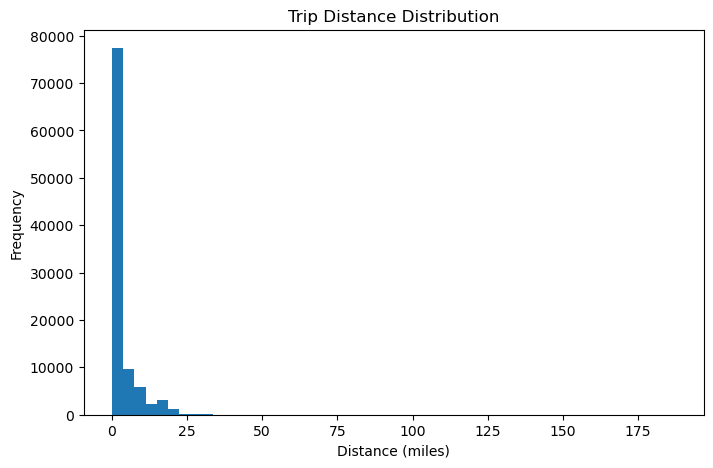

In [7]:
# Trip distance distribution
plt.figure(figsize=(8,5))
plt.hist(sample_df["trip_distance"], bins=50)
plt.title("Trip Distance Distribution")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.show()

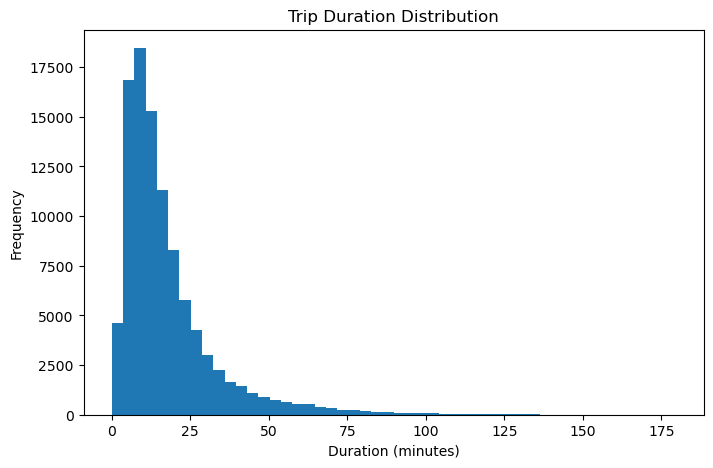

In [8]:
# Trip duration distribution
plt.figure(figsize=(8,5))
plt.hist(sample_df["trip_duration_min"], bins=50)
plt.title("Trip Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

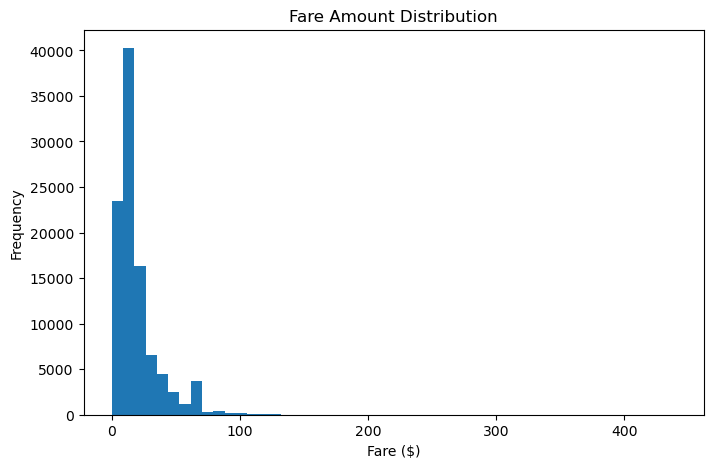

In [9]:
# Fare distribution
plt.figure(figsize=(8,5))
plt.hist(sample_df["fare_amount"], bins=50)
plt.title("Fare Amount Distribution")
plt.xlabel("Fare ($)")
plt.ylabel("Frequency")
plt.show()

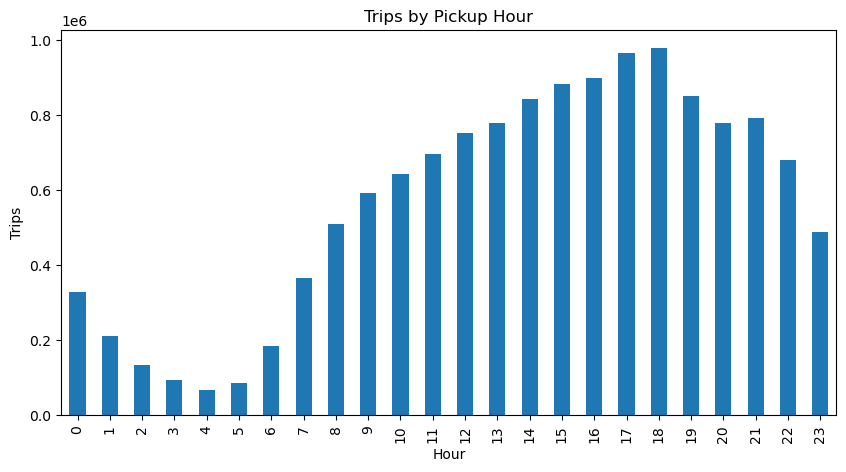

In [10]:
# Trips by pickup hour (use full dataset)
hourly = df.groupby("pickup_hour").size()

hourly.plot(kind="bar", figsize=(10,5))
plt.title("Trips by Pickup Hour")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

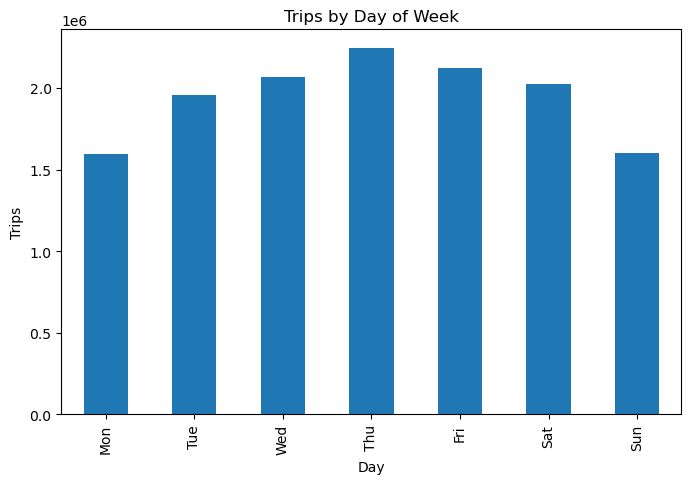

In [11]:
# Trips by day of week
daily = df.groupby("pickup_dayofweek").size()

daily.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

daily.plot(kind="bar", figsize=(8,5))
plt.title("Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Trips")
plt.show()

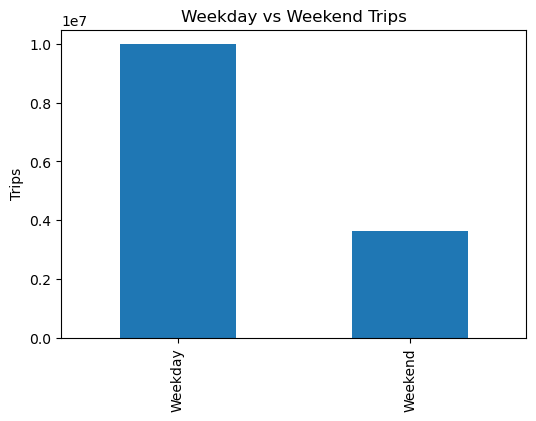

In [12]:
# Weekday vs Weekend
weekend = df.groupby("is_weekend").size()

weekend.index = ["Weekday", "Weekend"]

weekend.plot(kind="bar", figsize=(6,4))
plt.title("Weekday vs Weekend Trips")
plt.ylabel("Trips")
plt.show()

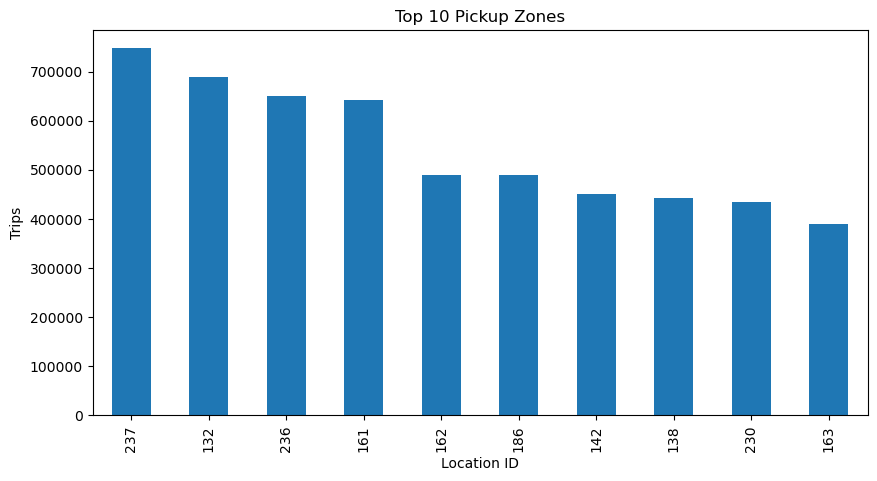

In [13]:
# Top 10 Pickup Zones
df["PULocationID"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Pickup Zones")
plt.xlabel("Location ID")
plt.ylabel("Trips")
plt.show()

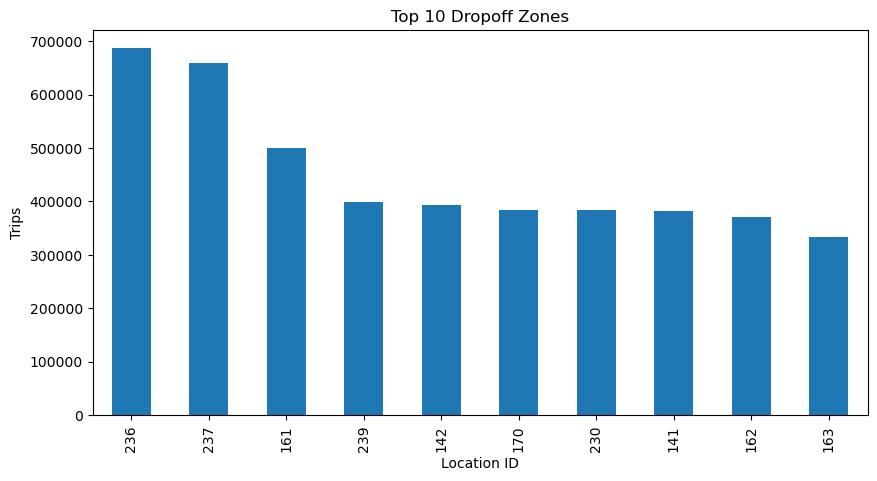

In [14]:
# Top 10 Dropoff Zones
df["DOLocationID"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Dropoff Zones")
plt.xlabel("Location ID")
plt.ylabel("Trips")
plt.show()

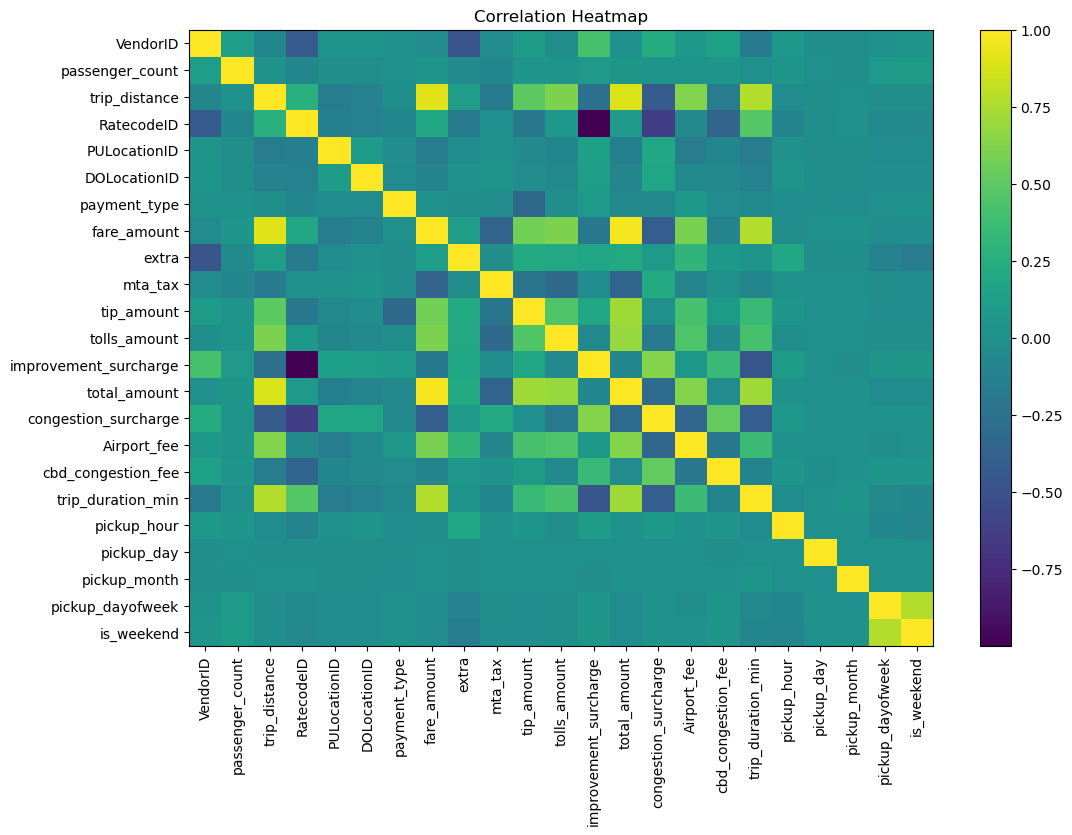

In [15]:
plt.figure(figsize=(12,8))

corr = sample_df.select_dtypes(include="number").corr()

plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
df.to_parquet("../data/processed/eda_completed.parquet", index=False)

# 02. Exploratory Data Analysis (EDA)

## Objectives
- Understand the characteristics of the cleaned dataset.
- Explore the distribution of important variables.
- Identify trends, patterns, and outliers.
- Discover relationships between features.
- Generate insights for feature engineering and model building.

---

## Steps Performed

### 1. Dataset Overview
- Shape
- Data types
- Summary statistics

### 2. Univariate Analysis
- Trip Distance Distribution
- Trip Duration Distribution
- Fare Amount Distribution
- Passenger Count Distribution

### 3. Time-Based Analysis
- Trips by Hour
- Trips by Day of Week
- Trips by Month
- Weekday vs Weekend Demand

### 4. Location Analysis
- Most Frequent Pickup Locations
- Most Frequent Dropoff Locations

### 5. Correlation Analysis
- Correlation Matrix
- Heatmap of Numerical Features



### 7. Key Insights
- Summarize important observations.
- Identify features useful for modeling.

---

## Output

A comprehensive understanding of the dataset that guides feature engineering and machine learning model development.
```